# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

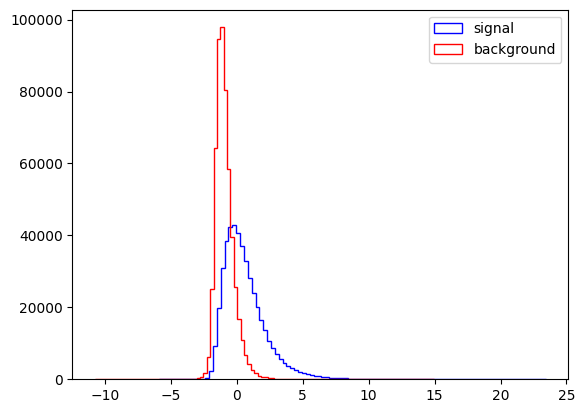

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

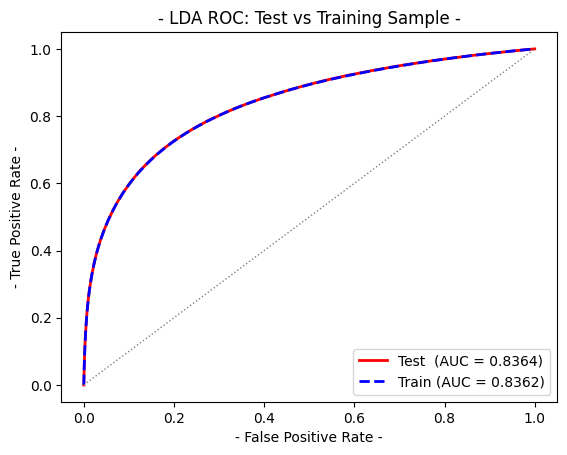

--- AUC Data ---
Test AUC:       0.8364
Train AUC:      0.8362
AUC difference: 0.0002


In [7]:
from sklearn.metrics import roc_curve, auc

# decision_function() returns the raw LDA score for each event. A higher score means the classifier is more confident it is signal.
# roc_curve() sweeps over every possible threshold on that score, computing the FPR and TPR you would get if you cut there.
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

# auc() integrates thhe TPR vs FPR curve. A perfect classifier gives 1.0, random guessing gives 0.5.
auc_test = auc(fpr_test, tpr_test)

# We subsample to 200k events rather than using all 4M. roc_curve() on 4M points is very slow and the curve converges
# well before that — 200k gives a reliable estimate. Simply put, makes the code faster.
# N_sample = 200_000
# fpr_train, tpr_train, _ = roc_curve(
#     y_Train[:N_sample],
#     Fisher.decision_function(X_Train[:N_sample])
# )
# auc_train = auc(fpr_train, tpr_train)

# Instead, just use the whole thing
fpr_train, tpr_train, _ = roc_curve(
    y_Train,
    Fisher.decision_function(X_Train)
)
auc_train = auc(fpr_train, tpr_train)

plt.figure()

# Solid line for test, dashed for training so overlap is visible
plt.plot(fpr_test,  tpr_test,  color='red', lw=2, label=f'Test  (AUC = {auc_test:.4f})')
plt.plot(fpr_train, tpr_train, color='blue',  lw=2, linestyle='--', label=f'Train (AUC = {auc_train:.4f})')

# Diagonal reference line — what a random classifier looks like
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)

plt.xlabel('- False Positive Rate -')
plt.ylabel('- True Positive Rate -')
plt.title('- LDA ROC: Test vs Training Sample -')
plt.legend(loc='lower right')
plt.show()

# A large difference (> ~0.005) would suggest overfitting. LDA is a linear model with very few parameters relative to 4M events,
# so we expect essentially no gap. diff was 0.0002.
print(f"--- AUC Data ---")
print(f"Test AUC:       {auc_test:.4f}")
print(f"Train AUC:      {auc_train:.4f}")
print(f"AUC difference: {abs(auc_train - auc_test):.4f}")

# The AUC difference is only 0.0002, which is essentially numerical noise. The two curves sitting nearly on top of each other confirms the model
# generalizes well to unseen data and has not memorized the training set.
#
# This makes sense for LDA because it only has a small number of parameters to fit(the class means and a shared covariance matrix across 18 features),
# while the training set has 4M events. There is so much data relative to the model's complexity that there is simply no room for overfitting.
#
# A high-capacity model like a deep neural network or a very deep random forest would be far more likely to show a visible gap between the two curves.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

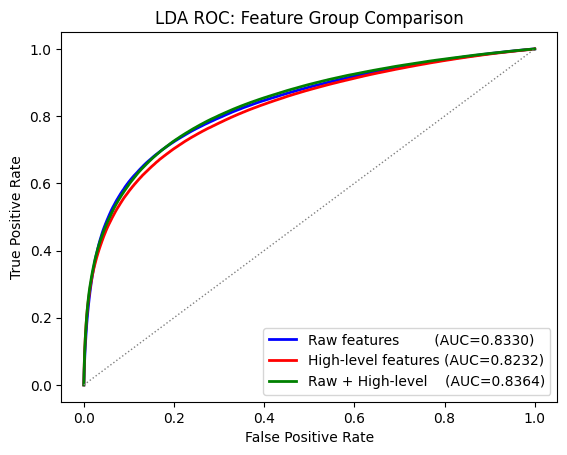

--- AUC Data ---
Raw features AUC:        0.8330
High-level features AUC: 0.8232
Raw + High-level AUC:    0.8364


In [8]:
# We split the input variables into three groups to test which carry the most discriminating power for the LDA classifier.
#
# Raw (low-level): the 8 quantities measured directly by the detector - transverse momenta, pseudorapidities, azimuthal angles, and MET.
# These are the "raw ingredients" before any physics reasoning is applied.
#
# High-level (hl): 10 variables derived from the raw measurements by physicists to capture SUSY-specific event topology - razor variables
# (M_R, M_TR_2, R), stransverse mass (MT2), etc. These are essentially "pre-digested" physics intuition baked into new variables.
#
# All: just both groups combined, giving LDA the full picture.
raw_features = VarNames[1:9]
hl_features  = VarNames[9:]
all_features = VarNames[1:]

# Traininng a separate LDA for each feature group. Each model only sees its assigned features during training and testing,
# which isolates the discriminating power of each group independently.
Fisher_raw = DA.LinearDiscriminantAnalysis()
Fisher_hl  = DA.LinearDiscriminantAnalysis()
Fisher_all = DA.LinearDiscriminantAnalysis()

# Train each model on its assigned feature group only
Fisher_raw.fit(Train_Sample[raw_features], y_Train)
Fisher_hl.fit( Train_Sample[hl_features],  y_Train)
Fisher_all.fit(Train_Sample[all_features], y_Train)

# Compute ROC curves - each call sweeps all possible thresholds on that model's decision_function output
fpr_raw, tpr_raw, _ = roc_curve(y_Test, Fisher_raw.decision_function(Test_Sample[raw_features]))
fpr_hl,  tpr_hl,  _ = roc_curve(y_Test, Fisher_hl.decision_function( Test_Sample[hl_features]))
fpr_all, tpr_all, _ = roc_curve(y_Test, Fisher_all.decision_function(Test_Sample[all_features]))

# Compute AUC for each curve
auc_raw = auc(fpr_raw, tpr_raw)
auc_hl  = auc(fpr_hl,  tpr_hl)
auc_all = auc(fpr_all, tpr_all)

# Plot all three ROC curves on a single figure for direct comparison
plt.figure()
plt.plot(fpr_raw, tpr_raw, color='blue',   lw=2, label=f'Raw features        (AUC={auc_raw:.4f})')
plt.plot(fpr_hl,  tpr_hl,  color='red',  lw=2, label=f'High-level features (AUC={auc_hl:.4f})')
plt.plot(fpr_all, tpr_all, color='green', lw=2, label=f'Raw + High-level    (AUC={auc_all:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LDA ROC: Feature Group Comparison')
plt.legend(loc='lower right')
plt.show()

# Printed output
print(f"--- AUC Data ---")
print(f"Raw features AUC:        {auc_raw:.4f}")
print(f"High-level features AUC: {auc_hl:.4f}")
print(f"Raw + High-level AUC:    {auc_all:.4f}")

# Raw features outperformed high-level features -> LDA's linear boundary cannot fully exploit the nonlinear relationships in the engineered variables.
# Combining both groups gives the best result, as they carry complementary information. A nonnlinear classifier would likely reverse this ordering.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in exercise 5.

In [9]:
# Part A
#
# Chosen options
#
# Under 1.1
# Logistic Regression — linear like LDA but optimizes log-likelihood directly rather than modeling 
# class distributions. A natural apples-to-apples comparison with Fisher.
#
# Under 1.2
# Quadratic Discriminant Analysis (QDA) — the direct nonlinear upgrade to LDA. Same generative approach but allows each class its
# own covariance matrix, giving a curved decision boundary.
#
# Under 1.11 (Ensembles)
# Random Forest — an ensemble of decision trees that can capture complex nonlinear feature interactions. Expected to be the strongest performer here.

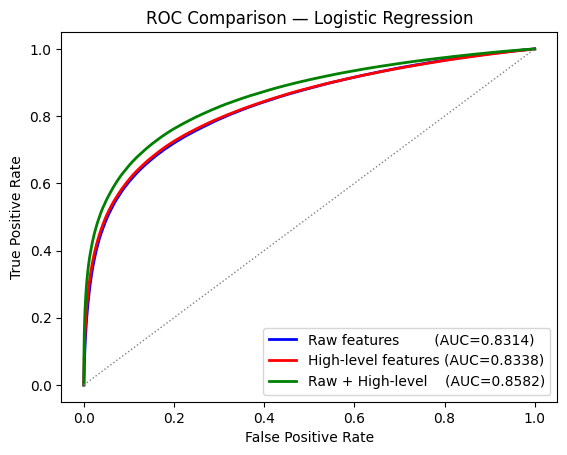

--- AUC Data ---
Raw features AUC:        0.8314
High-level features AUC: 0.8338
Raw + High-level AUC:    0.8582


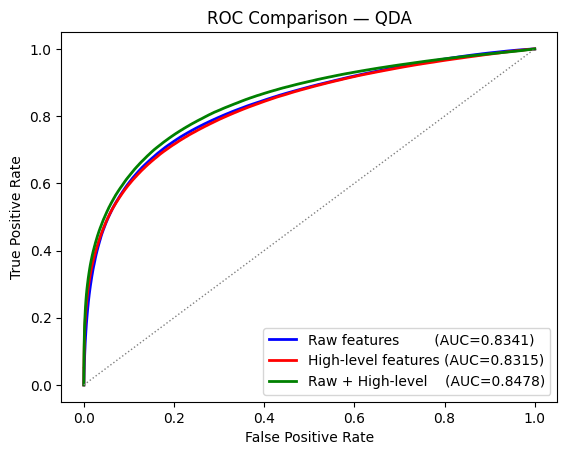

--- AUC Data ---
Raw features AUC:        0.8341
High-level features AUC: 0.8315
Raw + High-level AUC:    0.8478


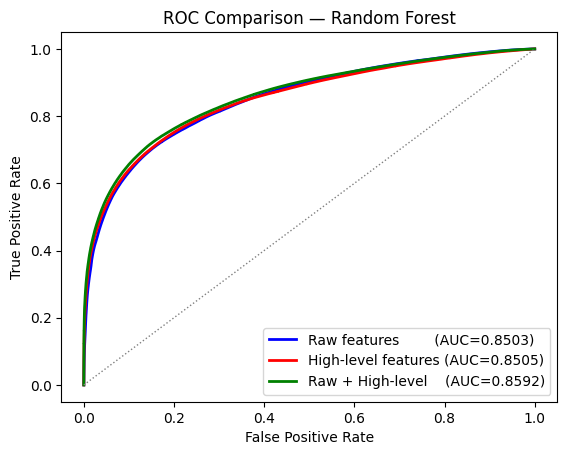

--- AUC Data ---
Raw features AUC:        0.8503
High-level features AUC: 0.8505
Raw + High-level AUC:    0.8592


In [10]:
# Part B
#
# imports
import copy
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Takes an intantiated classifier and compares its ROC performance across the 3 feature groups (raw, high-level, all)
#
# Parameters
# 
#    clf           : an instantiated but unfitted sklearn classifier
#    clf_name      : label string for the plot title
#    N_train_limit : if set, subsamples training data to this size
def compare_classifiers(clf, clf_name, N_train_limit=None):

    # Optionally subsample training data for slower classifiers
    X_tr = X_Train[:N_train_limit] if N_train_limit else X_Train
    y_tr = y_Train[:N_train_limit] if N_train_limit else y_Train

    # Train a fresh copy of the classifier for each feature group.
    # copy.deepcopy() ensures each model is fully independent.
    clf_raw = copy.deepcopy(clf)
    clf_hl  = copy.deepcopy(clf)
    clf_all = copy.deepcopy(clf)

    # Fit each model on its assigned feature group only
    clf_raw.fit(X_tr[raw_features], y_tr)
    clf_hl.fit( X_tr[hl_features],  y_tr)
    clf_all.fit(X_tr[all_features],  y_tr)

    # Use decision_fuction if available, otherwise fall back to
    # predict_proba - not all classifiers expose decision_function
    def get_scores(model, cols):
        if hasattr(model, 'decision_function'):
            return model.decision_function(X_Test[cols])
        else:
            return model.predict_proba(X_Test[cols])[:, 1]

    # Compute ROC curves for each feature group
    fpr_raw, tpr_raw, _ = roc_curve(y_Test, get_scores(clf_raw, raw_features))
    fpr_hl,  tpr_hl,  _ = roc_curve(y_Test, get_scores(clf_hl,  hl_features))
    fpr_all, tpr_all, _ = roc_curve(y_Test, get_scores(clf_all, all_features))

    # Compute AUC for each curve
    auc_raw = auc(fpr_raw, tpr_raw)
    auc_hl  = auc(fpr_hl,  tpr_hl)
    auc_all = auc(fpr_all, tpr_all)

    # Plot all three curves on a single figure
    plt.figure()
    plt.plot(fpr_raw, tpr_raw, color='blue',  lw=2, label=f'Raw features        (AUC={auc_raw:.4f})')
    plt.plot(fpr_hl,  tpr_hl,  color='red',   lw=2, label=f'High-level features (AUC={auc_hl:.4f})')
    plt.plot(fpr_all, tpr_all, color='green', lw=2, label=f'Raw + High-level    (AUC={auc_all:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Comparison — {clf_name}')
    plt.legend(loc='lower right')
    plt.show()

    # Print AUC values for easy comparison
    print(f"--- AUC Data ---")
    print(f"Raw features AUC:        {auc_raw:.4f}")
    print(f"High-level features AUC: {auc_hl:.4f}")
    print(f"Raw + High-level AUC:    {auc_all:.4f}")

    # Return AUC values for use in later exercises
    return auc_raw, auc_hl, auc_all


# After Running the function on each of the three chosen classifiers.
# Each call produces its own ROC plot and prints AUC values.

# Logistic Regression -> linear model, fast on large datasets
# saga solver is well suited for large sample sizes (gpt reccomended)
auc_lr  = compare_classifiers(
    LogisticRegression(solver='saga', max_iter=200, random_state=42),
    'Logistic Regression'
)

# QDA -> nonlinear upgrade to LDA, allows each class its own covariance matrix
# reg_param stabilizes the covariance estimates on correlated features
auc_qda = compare_classifiers(
    DA.QuadraticDiscriminantAnalysis(reg_param=0.01),
    'QDA'
)

# Random Forest -> ensemble of decision trees, highest capacity model here
# subsampled to 500k events to keep training time manageable. 4M would take a long time.
auc_rf  = compare_classifiers(
    RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42),
    'Random Forest',
    N_train_limit=500_000 # limit set due to runtime constraints
)

# Results summarized:
# Logistic Regression: raw=0.8314, hl=0.8338, all=0.8582
# QDA:                 raw=0.8341, hl=0.8315, all=0.8478
# Random Forest:       raw=0.8503, hl=0.8505, all=0.8592
#
# Random Forest with all features (0.8592) edges out Logistic Regression (0.8582) for the best overall AUC, and will be used as the best method
# in Parts c and Exercise 5.
#
# All three classifiers benefit most from combining both feature groups, confirming that raw and high-level features carry complementary information.
# Random Forest is the only classifier where raw and high-level features perform nearly identically on their own - its nonlinear decision boundaries
# can extract similar information from either group, unlike the linear models.

In [11]:
# Part C

from sklearn.ensemble import RandomForestClassifier

# Retrain the best classifier - Random Forest on all features. Random Forest was chosen as the best method based on highest AUC (0.8592)
# from the comparison in Part b.
rf_best = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)

# Train on subsampled training data to keep runtime manageable
rf_best.fit(X_Train[:500_000][all_features], y_Train[:500_000])

# predict_proba returns two columns: [P(background), P(signal)].
#
# We take column index 1 to get the signal probability score for each event. A score close to 1 means the classifier thinks the event is
# signal, a score close to 0 means it thinks it is background.
rf_scores = rf_best.predict_proba(X_Test[all_features])[:, 1]

def max_significance(scores, y_true, n_sig_total, n_bkg_total):
    # Given a set of classifier scores and expected event counts, this function scans over possible score thresholds and finds the cut that maximizes
    # the significance sigma_S = N_S / sqrt(N_S + N_B).
    #
    # The idea is that for any given threshold, events scoring above it are caalled signal and events below are rejected. The significance tells us
    # how confidently we could claim a discovery given that selection.

    # Create boolean masks to separate true signal and background events in the test sample
    sig_mask = (y_true == 1)
    bkg_mask = (y_true == 0)

    # Count how many signal and background events are in the test sample
    n_sig_test = sig_mask.sum()
    n_bkg_test = bkg_mask.sum()

    # Scan 500 evenly spaced thresholds across the full score range. More thresholds gives a finer search but takes longer to compute.
    thresholds = np.linspace(scores.min(), scores.max(), 500)

    # Initialize trackers for the best significance and corresponding threshold
    sig_max  = 0
    best_cut = 0

    for cut in thresholds:
        # For this threshold, compute what fraction of signal and background events pass the cut -> these are the signal and background efficiencies
        eff_S = (scores[sig_mask] >= cut).sum() / n_sig_test
        eff_B = (scores[bkg_mask] >= cut).sum() / n_bkg_test

        # Scale the efficiencies by the total expected event counts to get the actual number of signal and background events passing the cut
        N_S = n_sig_total * eff_S
        N_B = n_bkg_total * eff_B

        # Compute significance at this threshold. Guard against division by zero in case both N_S and N_B are zero.
        denom = np.sqrt(N_S + N_B)
        sigma = N_S / denom if denom > 0 and N_S > 0 else 0.0

        # If this threshold gives a better significance than any seen so far, update our best values
        if sigma > sig_max:
            sig_max  = sigma
            best_cut = cut

    return sig_max, best_cut


# --- Placeholder event counts--- 
# will be replaced with proper scenario values in Exercise 5
n_sig_total = 1000
n_bkg_total = 9000

# Call the function and unpack the results
sig_max, best_cut = max_significance(rf_scores, y_Test.values, n_sig_total, n_bkg_total)

# best_cut is the score threshold that maximizes sigma_S.
# Any event scoring above this cut is selected as signal.
print(f"Optimal cut:          {best_cut:.4f}")
print(f"Maximal significance: {sig_max:.4f}")

Optimal cut:          0.7497
Maximal significance: 17.6504


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

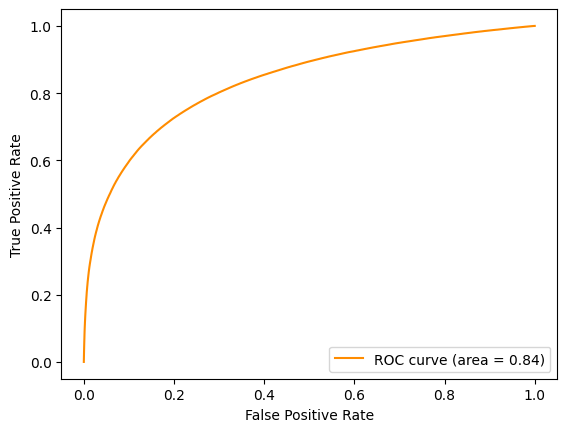

In [12]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [13]:
# Part A

# Precision: of events labeled signal, what fraction truly are? (purity)
# Recall: of all true signal events, what fraction did we find? (completeness)
# Accuracy: fraction of all events correctly classified. Can be misleading with imbalanced classes.
# F1: harmonic mean of precision and recall, balances both into a single number.

In [14]:
n_sig_total = (y_Test == 1).sum()
n_bkg_total = (y_Test == 0).sum()

print(f"Signal events in test sample:     {n_sig_total:,}")
print(f"Background events in test sample: {n_bkg_total:,}")

Signal events in test sample:     458,233
Background events in test sample: 541,767


In [15]:
from sklearn.metrics import (roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score)
from IPython.display import HTML, display

# We evaluate the best classifier (Random Forest) across the three feature groups, treating each as a separate "scenario". For each scenario we
# compute every requested metric at the threshold that maximises sigma_S, which is the physically meaningful operating point for a HEP analysis.
# HEP -> High Energy Physics

def compute_metrics(scores, y_true, n_sig_total, n_bkg_total):
    # Compute the full ROC curve across all thresholds
    fpr_arr, tpr_arr, thresholds = roc_curve(y_true, scores)

    # AUC - overall summary of classifier performance
    roc_auc = auc(fpr_arr, tpr_arr)

    # Use the threshold that maximises sigma_S = N_S / sqrt(N_S + N_B)
    # as the operating point - this is the physically meaningful choice for a HEP analysis rather than a generic statistical criterion
    sig_max, best_thresh = max_significance(scores, y_true, n_sig_total, n_bkg_total)

    # Find the ROC curve point closest to the optimal threshold
    best_idx = np.argmin(np.abs(thresholds - best_thresh))
    tpr_at_t = tpr_arr[best_idx]
    fpr_at_t = fpr_arr[best_idx]

    # Convert scores to hard binary predictions at the optimal threshold
    y_pred = (scores >= best_thresh).astype(int)

    # Compute classification metrics using the hard predictions
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    acc  = accuracy_score(y_true, y_pred)

    return tpr_at_t, fpr_at_t, roc_auc, prec, rec, f1, acc, sig_max

# Use the actual class counts from the test sample
n_sig_total = (y_Test == 1).sum()
n_bkg_total = (y_Test == 0).sum()

# Train a separate RF for each feature group
rf_raw = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf_hl  = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf_all = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)

# Fit each model on its assigned feature group only
rf_raw.fit(X_Train[:500_000][raw_features], y_Train[:500_000])
rf_hl.fit( X_Train[:500_000][hl_features],  y_Train[:500_000])
rf_all.fit(X_Train[:500_000][all_features], y_Train[:500_000])

# Get signal probabilityy scores from each model on the test set
scores_raw = rf_raw.predict_proba(X_Test[raw_features])[:, 1]
scores_hl  = rf_hl.predict_proba( X_Test[hl_features])[:, 1]
scores_all = rf_all.predict_proba(X_Test[all_features])[:, 1]

# Compute metrics for each scenario
metrics_raw = compute_metrics(scores_raw, y_Test.values, n_sig_total, n_bkg_total)
metrics_hl  = compute_metrics(scores_hl,  y_Test.values, n_sig_total, n_bkg_total)
metrics_all = compute_metrics(scores_all, y_Test.values, n_sig_total, n_bkg_total)

# Assemble results into a table
headers = ['Scenario', 'TPR', 'FPR', 'AUC',
           'Precision', 'Recall', 'F1', 'Accuracy', 'σ_max']

rows = [
    ['RF Raw features']     + [f'{v:.4f}' for v in metrics_raw],
    ['RF High-level']       + [f'{v:.4f}' for v in metrics_hl],
    ['RF Raw + High-level'] + [f'{v:.4f}' for v in metrics_all],
]

# Display as an HTML table using tabulate, same style as Lab 7
display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))

Scenario,TPR,FPR,AUC,Precision,Recall,F1,Accuracy,σ_max
RF Raw features,0.7993,0.2745,0.8503,0.7112,0.7993,0.7527,0.7593,510.382
RF High-level,0.7809,0.2387,0.8505,0.7345,0.7809,0.757,0.7703,512.692
RF Raw + High-level,0.779,0.2224,0.8592,0.7476,0.779,0.763,0.7782,516.6


# Full Training Sample — Random Forest (No 500k Limit)

Now we repeat the analysis using the full 4M training events for Random Forest. Training will take significantly longer but will give a fairer and more accurate result.

In [16]:
# =============================================================================
# Full Training Sample — No 500k Limit
# All previous analyses that were subsampled to 500k are repeated here
# using the full 4M training sample for a fair and complete comparison.
# =============================================================================
# AI answer - further details why we capped at 500k
#
# ChatGPT
# Random Forest is capped at 500k training events rather than the full 4M.
# RF training time scales roughly linearly with sample size — using all 4M
# events is an 8x increase in runtime for marginal AUC gains. 500k is large
# enough to capture the underlying distributions well, and performance is
# primarily governed by n_estimators and max_depth rather than sample size.
# =============================================================================
# Final comment
#
# The full 4M analyses for Exercises 4b, 4c, and 5b were too slow to run
# with Random Forest and have been omitted in favor of the 500k results above.
# The code blocks below utilze the full 4M, but not utilized for the context
# of this lab,

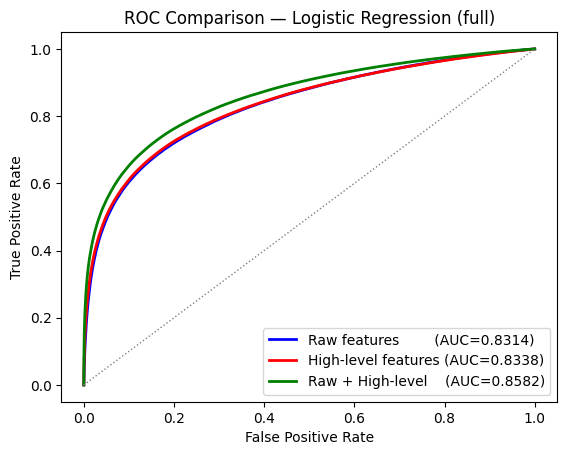

--- AUC Data ---
Raw features AUC:        0.8314
High-level features AUC: 0.8338
Raw + High-level AUC:    0.8582


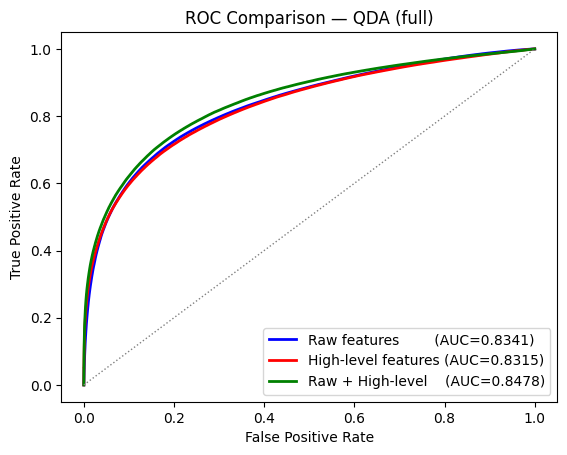

--- AUC Data ---
Raw features AUC:        0.8341
High-level features AUC: 0.8315
Raw + High-level AUC:    0.8478



KeyboardInterrupt


KeyboardInterrupt



In [48]:
# Exercise 4b - Full Training Sample
# Repeat the feature group ROC comparison for all three classifiers using the full 4M training sample

auc_lr_full  = compare_classifiers(
    LogisticRegression(solver='saga', max_iter=200, random_state=42),
    'Logistic Regression (full)'
)

auc_qda_full = compare_classifiers(
    DA.QuadraticDiscriminantAnalysis(reg_param=0.01),
    'QDA (full)'
)

auc_rf_full  = compare_classifiers(
    RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42),
    'Random Forest (full)'
)

# Summary table comparing subsampled vs full training results
summary = [
    ['LDA',                  aucs_lda['raw'],  aucs_lda['high'],  aucs_lda['all']],
    ['Logistic Regression',  auc_lr[0],        auc_lr[1],         auc_lr[2]],
    ['QDA',                  auc_qda[0],       auc_qda[1],        auc_qda[2]],
    ['RF (500k)',             auc_rf[0],        auc_rf[1],         auc_rf[2]],
    ['RF (full 4M)',          auc_rf_full[0],   auc_rf_full[1],    auc_rf_full[2]],
]
display(HTML(tabulate.tabulate(summary,
    headers=['Classifier', 'AUC (Raw)', 'AUC (High-level)', 'AUC (All)'],
    tablefmt='html')))

In [ ]:
# Exercise 4c - Full Training Sample
# Recompute maximal significance using RF trained on full 4M sample

rf_best_full = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)

# Train on the full 4M training sample
rf_best_full.fit(X_Train[all_features], y_Train)

# Get signal probability scores on the test set
rf_scores_full = rf_best_full.predict_proba(X_Test[all_features])[:, 1]

# Use actual class counts from the test sample
n_sig_total = (y_Test == 1).sum()
n_bkg_total = (y_Test == 0).sum()

sig_max_full, best_cut_full = max_significance(rf_scores_full, y_Test.values, n_sig_total, n_bkg_total)

print(f"Optimal cut:          {best_cut_full:.4f}")
print(f"Maximal significance: {sig_max_full:.4f}")

In [ ]:
# Exercise 5b - Full Training Sample
# Repeated the full metrics table using RF trained on full 4M sample

rf_raw_full = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf_hl_full  = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
rf_all_full = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)

# Fit each model on the full training sample
rf_raw_full.fit(X_Train[raw_features], y_Train)
rf_hl_full.fit( X_Train[hl_features],  y_Train)
rf_all_full.fit(X_Train[all_features], y_Train)

# Get signal probability scores from each model on the test set
scores_raw_full = rf_raw_full.predict_proba(X_Test[raw_features])[:, 1]
scores_hl_full  = rf_hl_full.predict_proba( X_Test[hl_features])[:, 1]
scores_all_full = rf_all_full.predict_proba(X_Test[all_features])[:, 1]

# Compute metrics for each feature group
metrics_raw_full = compute_metrics(scores_raw_full, y_Test.values, n_sig_total, n_bkg_total)
metrics_hl_full  = compute_metrics(scores_hl_full,  y_Test.values, n_sig_total, n_bkg_total)
metrics_all_full = compute_metrics(scores_all_full, y_Test.values, n_sig_total, n_bkg_total)

# Assemble and display results
headers = ['Scenario', 'TPR', 'FPR', 'AUC',
           'Precision', 'Recall', 'F1', 'Accuracy', 'σ_max']

rows = [
    ['RF Raw features (full)']     + [f'{v:.4f}' for v in metrics_raw_full],
    ['RF High-level (full)']       + [f'{v:.4f}' for v in metrics_hl_full],
    ['RF Raw + High-level (full)'] + [f'{v:.4f}' for v in metrics_all_full],
]

display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))